## Import Library

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from  nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
import sys




In [4]:
sys.path.append('..')
from src.load_data import load_data
data = load_data('../data/raw_analyst_ratings.csv')
data.columns

Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='object')

## Describing Statistic




In [5]:
head_line_length = data['headline'].str.len()
print("headline statistics:")
head_line_length.describe()

headline statistics:


count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline, dtype: float64

## Analyzing the Publisher

In [7]:

active_publisher = data['publisher'].value_counts()
print(f"The most active publisher is {active_publisher.index[0]} with {active_publisher.iloc[0]} articles")
active_publisher[:10]

The most active publisher is Paul Quintaro with 228373 articles


publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

In [11]:
## Time based Analysis
data['date'] = pd.to_datetime(data['date'], errors='coerce')
daily_count = data.groupby(data['date'].dt.date).size()
weekly_count = data.groupby(data['date'].dt.day_name()).size()
monthly_count = data.groupby(data['date'].dt.month).size()
hourly_count = data.groupby(data['date'].dt.hour).size()

## Text Analysis(Topic Modeling):

In [8]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Most common words in Headline

In [9]:
stop_words = set(stopwords.words('english'))
filtered_words = []
for text in data['headline']:
    tokens = word_tokenize(text.lower())
    for word in tokens:
        if word not in stop_words and word.isalpha():
            filtered_words.append(word)
pd.Series(filtered_words).value_counts()[:10]

stocks      161702
vs          138835
eps         128801
est         122289
shares      114140
reports     108688
update       91645
market       91080
earnings     87183
sales        79528
Name: count, dtype: int64

## Time Series Analysis

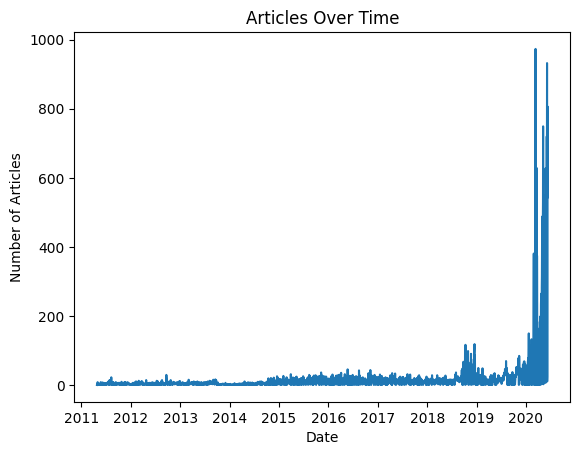

The busiest date is 2020-03-12 with 973 articles.


In [12]:

daily_count.plot()
plt.title("Articles Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.show()
print(f"The busiest date is {daily_count.idxmax()} with {daily_count.max()} articles.")

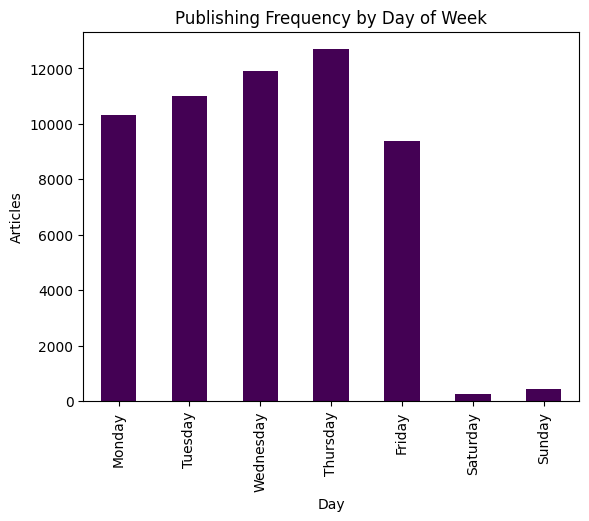

The most active day is Thursday with 12688 articles.


In [13]:
weekly_count.reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]).plot(kind='bar', colormap='viridis')
plt.title("Publishing Frequency by Day of Week")
plt.xlabel("Day")
plt.ylabel("Articles")
plt.show()
print(f"The most active day is {weekly_count.idxmax()} with {weekly_count.max()} articles.")

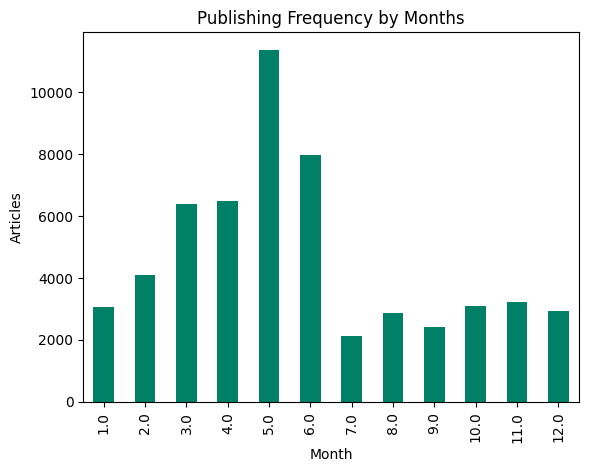

The most active month is Month 5.0 with 11363 articles.


In [14]:
monthly_count.plot(kind='bar', colormap='summer')
plt.title("Publishing Frequency by Months")
plt.xlabel("Month")
plt.ylabel("Articles")
plt.show()
print(f"The most active month is Month {monthly_count.idxmax()} with {monthly_count.max()} articles.")

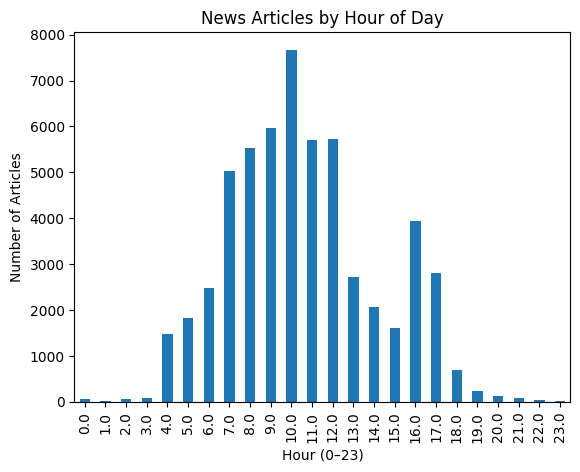

The most active hour is 10.0 o'clock  with 7669 articles.


In [15]:

hourly_count.plot(kind='bar')
plt.title("News Articles by Hour of Day")
plt.xlabel("Hour (0–23)")
plt.ylabel("Number of Articles")
plt.show()
print(f"The most active hour is {hourly_count.idxmax()} o'clock  with {hourly_count.max()} articles.")

## Publisher Analysis

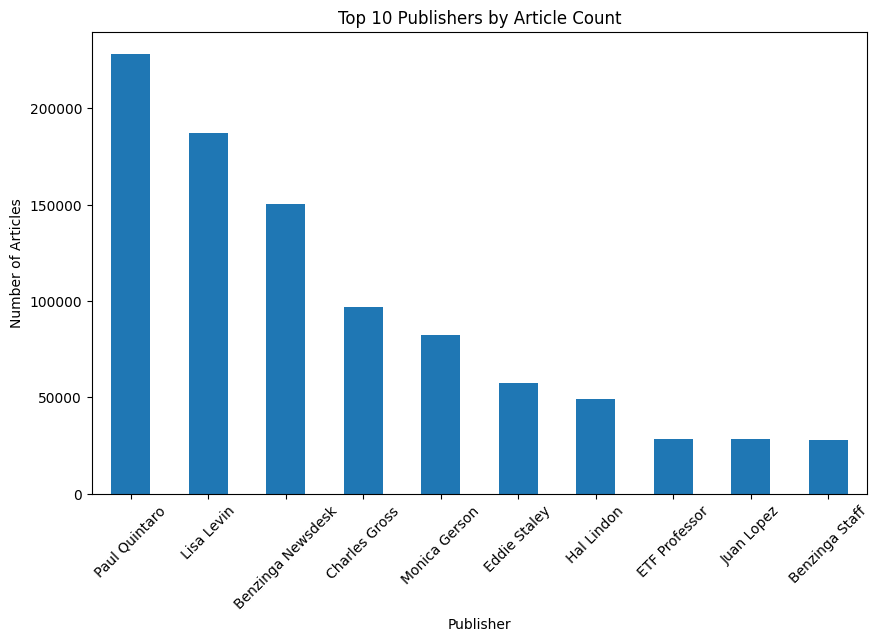

In [16]:
plt.figure(figsize=(10,6))
active_publisher[:10].plot(kind='bar')
plt.title("Top 10 Publishers by Article Count")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.show()

In [17]:
stop_words = set(stopwords.words('english'))
def extract_keywords(text):
    tokens= word_tokenize(text.lower())
    return [word for word in tokens if word not in stop_words and word.isalpha()]
    

In [18]:
publisher_topics = {}
for pub in active_publisher.index[:10]:
    pub_text = " ".join(data[data['publisher'] == pub]['headline'])
    words = extract_keywords(pub_text)
    publisher_topics[pub] = Counter(words).most_common(10)

In [19]:
for pub, keywords in list(publisher_topics.items())[:5]:
    print(f"Top keywords for {pub}:")
    print(keywords)

Top keywords for Paul Quintaro:
[('vs', 75009), ('est', 69697), ('eps', 57004), ('reports', 55265), ('sales', 31407), ('shares', 22798), ('sees', 20730), ('announces', 20374), ('pt', 15393), ('revenue', 14690)]
Top keywords for Lisa Levin:
[('stocks', 68373), ('moving', 32324), ('session', 32324), ('top', 31267), ('market', 30329), ('biggest', 29090), ('benzinga', 28547), ('update', 23073), ('movers', 22473), ('earnings', 20949)]
Top keywords for Benzinga Newsdesk:
[('shares', 42666), ('trading', 38834), ('estimate', 29403), ('stocks', 27841), ('eps', 27419), ('sales', 27375), ('companies', 22019), ('new', 21404), ('several', 19667), ('higher', 19010)]
Top keywords for Charles Gross:
[('vs', 16641), ('option', 15732), ('alert', 15673), ('ask', 12076), ('oi', 11205), ('says', 8237), ('est', 8162), ('sweep', 8110), ('calls', 7786), ('earnings', 7634)]
Top keywords for Monica Gerson:
[('top', 28151), ('stocks', 24821), ('earnings', 19526), ('scheduled', 16625), ('benzinga', 13791), ('indu

In [20]:
def extract_name(publisher):
    if '@' in str(publisher):
        return publisher.split('@')[-1].lower()
    return 'unKnown'
publisher_domain = data['publisher'].apply(extract_name)
publisher_domain.value_counts()[:10]

publisher
unKnown                   1399240
benzinga.com                 7937
gmail.com                     139
andyswan.com                    5
investdiva.com                  2
tothetick.com                   2
eosdetroit.io                   1
forextraininggroup.com          1
stockmetrix.net                 1
Name: count, dtype: int64